# Excercise: Wolff Algorithm
1. Repeat the simulation as the previous assignment but using Wolff cluster algorithm.
2. Tasks: Plot the magnetization and energy as the function of $\beta$.
3. Compare Metropolis and Wolff cluster algorithm.

## Imports

In [43]:
from collections import deque

from copy import deepcopy
import time

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

## Grid init

In [44]:
N = 20
grid_cold = np.ones((N, N))*-1
grid_random = np.random.choice(a=[-1,1], size=(N,N), replace=True)
grid_hot = np.ones((N,N))
print(grid_random)

[[ 1  1 -1  1 -1  1  1 -1  1 -1  1  1 -1 -1  1  1 -1  1 -1  1]
 [-1 -1 -1 -1 -1  1  1 -1  1  1  1  1 -1  1  1 -1 -1 -1 -1 -1]
 [-1  1 -1 -1  1 -1  1  1 -1  1  1 -1  1  1  1 -1  1  1  1  1]
 [ 1  1 -1  1 -1  1  1  1 -1  1 -1  1 -1 -1  1  1 -1 -1  1  1]
 [ 1  1 -1  1 -1 -1 -1  1 -1 -1 -1  1  1  1 -1 -1 -1 -1  1  1]
 [-1 -1  1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1  1 -1  1]
 [-1 -1  1  1 -1  1  1  1 -1  1 -1 -1  1  1  1  1 -1  1 -1  1]
 [-1  1 -1 -1  1  1 -1  1  1 -1  1  1 -1  1 -1  1 -1 -1 -1 -1]
 [-1  1 -1 -1  1  1  1 -1  1  1 -1  1 -1 -1  1 -1 -1 -1 -1 -1]
 [ 1  1 -1  1 -1 -1 -1  1 -1  1 -1 -1 -1 -1 -1 -1  1 -1 -1  1]
 [-1  1  1 -1  1  1 -1  1  1 -1  1 -1 -1  1  1  1 -1 -1 -1 -1]
 [-1 -1 -1  1 -1 -1  1  1  1 -1 -1  1 -1 -1  1 -1 -1  1  1  1]
 [ 1 -1 -1  1 -1  1 -1  1  1 -1 -1  1  1  1  1 -1 -1 -1  1  1]
 [-1 -1 -1  1 -1 -1  1  1 -1  1 -1  1  1  1  1 -1  1 -1 -1  1]
 [-1  1  1 -1  1  1 -1 -1  1 -1 -1  1 -1 -1 -1  1 -1 -1  1  1]
 [-1 -1 -1  1 -1 -1  1 -1  1 -1 -1  1  1  1  1 -1  1  1

## Help funcs

In [45]:
def get_total_energy_system(grid, J=1.0, B=0.0):
    right_neighbours = np.roll(grid, 1, axis=1)
    down_neighbours = np.roll(grid, 1, axis=0)

    spin_sum = -1 * J * np.sum(grid * (right_neighbours + down_neighbours))

    if B != 0.0:
        field_sum = -1*B*np.sum(grid)
    else:
        field_sum = 0.0

    return spin_sum + field_sum

In [46]:
def visualize_grid(grid):
    cmap = plt.cm.coolwarm

    sns.heatmap(
        grid,
        cmap=cmap,
        vmin=-1,
        vmax=1,
        cbar=False,
    )

    plt.show()

In [47]:
def plot_comparison(mag_met, en_met, sus_met, mag_wolff, en_wolff, sus_wolff):
    # Konwersja na arraye
    m_met, e_met, s_met = np.array(mag_met), np.array(en_met), np.array(sus_met)
    m_wol, e_wol, s_wol = np.array(mag_wolff), np.array(en_wolff), np.array(sus_wolff)

    betas = np.arange(0, 1, 0.05)
    labels = ['Start: Hot (all 1)', 'Start: Cold (all -1)', 'Start: Random']

    # Kolory dla stanów (zostawiamy Twoje), ale różne style dla algorytmów
    colors = ['#d62728', '#1f77b4', '#2ca02c']
    critical_beta = 0.4407

    fig, axs = plt.subplots(3, 3, figsize=(18, 15), sharex=True)

    for i in range(3):
        # --- Rząd 1: Magnetyzacja ---
        axs[0, i].plot(betas, m_met[:, i], 'o--', color=colors[i], markersize=4, alpha=0.5, label='Metropolis')
        axs[0, i].plot(betas, m_wol[:, i], 's-', color=colors[i], markersize=5, label='Wolff')
        axs[0, i].set_title(f"Magnetization ({labels[i]})", fontweight='bold')

        # --- Rząd 2: Energia ---
        axs[1, i].plot(betas, e_met[:, i], 'o--', color=colors[i], markersize=4, alpha=0.5, label='Metropolis')
        axs[1, i].plot(betas, e_wol[:, i], 's-', color=colors[i], markersize=5, label='Wolff')
        axs[1, i].set_title(f"Total Energy ({labels[i]})", fontweight='bold')

        # --- Rząd 3: Podatność ---
        axs[2, i].plot(betas, s_met[:, i], 'o--', color=colors[i], markersize=4, alpha=0.5, label='Metropolis')
        axs[2, i].plot(betas, s_wol[:, i], 's-', color=colors[i], markersize=5, label='Wolff')
        axs[2, i].set_title(f"Susceptibility ({labels[i]})", fontweight='bold')
        axs[2, i].set_xlabel(r"Inverse Temperature $\beta$")

        # Dodatki dla każdego wykresu (linia krytyczna i grid)
        for row in range(3):
            axs[row, i].axvline(x=critical_beta, color='orange', linestyle=':', alpha=0.8)
            axs[row, i].grid(True, linestyle=':', alpha=0.4)
            if i == 0:
                ylabels = [r"$\langle |M| \rangle$", "Energy (E)", r"Susceptibility $\chi$"]
                axs[row, i].set_ylabel(ylabels[row])
            if row == 0:
                axs[row, i].legend(fontsize='small')

    # Globalna legenda dla linii krytycznej
    custom_lines = [plt.Line2D([0], [0], color='orange', linestyle=':')]
    fig.legend(custom_lines, ['Critical Beta (~0.44)'], loc='upper center', frameon=False)

    plt.suptitle("Comparison: Metropolis vs. Wolff Cluster Algorithm", fontsize=20, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [48]:
def plot_stats(mag,tot_en, sus, title_model):
    mag_arr = np.array(mag)
    en_arr = np.array(tot_en)
    sus_arr = np.array(sus)
    betas = np.arange(0, 1, 0.05)
    labels = ['Start: Hot (all 1)', 'Start: Cold (all -1)', 'Start: Random']
    colors = ['#d62728', '#1f77b4', '#2ca02c']
    critical_beta = 0.4407

    fig, axs = plt.subplots(3, 3, figsize=(18, 14), sharex=True)

    for i in range(3):
        # --- Row 1: Magnetization ---
        axs[0, i].plot(betas, mag_arr[:, i], 'o-', color=colors[i], markersize=4)
        axs[0, i].set_title(f"Magnetization ({labels[i]})", fontweight='bold')
        axs[0, i].axvline(x=critical_beta, color='orange', linestyle='--', alpha=0.5)
        axs[0, i].grid(True, linestyle=':', alpha=0.6)
        if i == 0: axs[0, i].set_ylabel(r"$\langle |M| \rangle$")

        # --- Row 2: Total Energy ---
        axs[1, i].plot(betas, en_arr[:, i], 's-', color=colors[i], markersize=4)
        axs[1, i].set_title(f"Total Energy ({labels[i]})", fontweight='bold')
        axs[1, i].axvline(x=critical_beta, color='orange', linestyle='--', alpha=0.5)
        axs[1, i].grid(True, linestyle=':', alpha=0.6)
        if i == 0: axs[1, i].set_ylabel("Energy (E)")

        # --- Row 3: Susceptibility ---
        axs[2, i].plot(betas, sus_arr[:, i], '^-', color=colors[i], markersize=4)
        axs[2, i].set_title(f"Susceptibility ({labels[i]})", fontweight='bold')
        axs[2, i].set_xlabel(r"Inverse Temperature $\beta$")
        axs[2, i].axvline(x=critical_beta, color='orange', linestyle='--', alpha=0.5)
        axs[2, i].grid(True, linestyle=':', alpha=0.6)
        if i == 0: axs[2, i].set_ylabel(r"Susceptibility $\chi$")

    axs[0, 0].plot([], [], color='orange', linestyle='--', label='Critical Beta (~0.44)')
    fig.legend(loc='upper center', ncol=1, frameon=False)

    plt.suptitle(f"2D Ising Model({title_model}): Statistical Properties vs. Inverse Temperature", fontsize=18, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## Algorithms

In [49]:
def monte_carlo_metropolis_step(grid, beta):
    def __boltzmann_probability(delta_e, beta):
        return np.exp(-beta * delta_e)

    def __local_spin_energy_change(grid, i, j, J=1, B=0):
        '''
        function switch the spin at specific index and checks how it would effect the total energy. Does not affect the grid

        :param grid: old grid
        :param i: x index in grid
        :param j: y index in grid
        :param J: interaction strength
        :param B: external field
        :return: value of local spin energy change
        '''
        N = len(grid)
        old_spin = grid[i, j]
        neighbours = (
            grid[(i-1)%N,j] +
            grid[(i+1)%N,j] +
            grid[i,(j-1)%N] +
            grid[i,(j+1)%N]
        )

        return 2 * old_spin  * (J * neighbours  + B)

    N = len(grid)

    for _ in range(N * N):
        random_index = np.random.randint(N * N)
        x_ind = random_index // N
        y_ind = random_index % N

        delta_e = __local_spin_energy_change(grid, x_ind, y_ind)

        # Logika Metropolis
        if delta_e <= 0:
            grid[x_ind, y_ind] *= -1
        else:
            if np.random.random() <= __boltzmann_probability(delta_e, beta):
                grid[x_ind, y_ind] *= -1

    return grid

In [50]:
def wolff_step(grid, beta, J=1.0):
    N = len(grid)
    random_index = np.random.randint(N * N)
    x_seed = random_index // N
    y_seed = random_index % N

    seed_spin = grid[x_seed, y_seed]
    cluster = {(x_seed, y_seed)}
    queue = deque([(x_seed, y_seed)])


    # accept prob
    acc_prob = 1.0 - np.exp(-2*beta*J)

    # neighbours checks
    while len(queue) > 0:
        x, y = queue.popleft()

        neighbours = (
            ((x-1)%N,y),
            ((x+1)%N,y),
            (x,(y-1)%N),
            (x,(y+1)%N)
        )

        # check neighbours
        for x_n, y_n in neighbours:
            # if in cluster or opposite spin -> we skip
            if ((x_n,y_n) not in cluster) and (grid[x_n,y_n] == seed_spin):
                if np.random.random() < acc_prob:
                    queue.append((x_n,y_n))
                    cluster.add((x_n,y_n))

    # cluster switching the spin
    for x, y in cluster:
        grid[x, y] *= -1

    return grid

## Simulators

In [51]:
def ising_simulation_with_stats(grid, step_func, beta, steps, burn_in_steps=0, verbose=False):
    active_steps = steps - burn_in_steps
    if active_steps <= 0:
        print("[WARNING] burn_in_steps is more or equal than the number of steps")
        return grid, 0, 0, 0

    _grid = deepcopy(grid)
    _sum_mag = 0.0
    _sum_mag_sq = 0.0
    _sum_en = 0.0  # Dodana zmienna do sumowania energii
    N_sq = len(grid)**2

    bar = range(steps)

    for i in bar:
        _grid = step_func(_grid, beta)

        if i >= burn_in_steps:
            # Obliczanie magnetyzacji
            current_m = np.abs(np.sum(_grid)) / N_sq
            _sum_mag += current_m
            _sum_mag_sq += current_m**2

            # Obliczanie energii i dodawanie do sumy (UŚREDNIANIE)
            current_e = get_total_energy_system(_grid, J=1, B=0.0)
            _sum_en += current_e

    # Statystyki końcowe
    _avg_mag = _sum_mag / active_steps
    _avg_mag_sq = _sum_mag_sq / active_steps
    _total_en = _sum_en / active_steps  # Średnia energia zamiast ostatniej wartości

    # Podatność magnetyczna: chi = beta * N^2 * (<m^2> - <m>^2)
    _susceptibility = beta * N_sq * (_avg_mag_sq - (_avg_mag**2))

    if verbose:
        print("Total magnetism (avg): ", _avg_mag,
              "Total energy (avg): ", _total_en,
              "Total susceptibility: ", _susceptibility, sep='\n')

    return _grid, _avg_mag, _total_en, _susceptibility

In [52]:
print("-="*5, "MCMC", "-="*5)
print("="*6, "Hot Grid", "="*6)
mcmc_grid_hot, _, _, _ = ising_simulation_with_stats(grid=grid_hot, step_func=monte_carlo_metropolis_step, beta=0.6, steps=5000, burn_in_steps=200, verbose=True)
print("="*6, "Cold Grid", "="*6)
mcmc_grid_cold, _, _, _ = ising_simulation_with_stats(grid=grid_cold, step_func=monte_carlo_metropolis_step, beta=0.6, steps=5000, burn_in_steps=200, verbose=True)
print("="*6, "Random Grid", "="*6)
mcmc_grid_rand, _, _, _ = ising_simulation_with_stats(grid=grid_random, step_func=monte_carlo_metropolis_step, beta=0.6, steps=5000, burn_in_steps=200, verbose=True)

-=-=-=-=-= MCMC -=-=-=-=-=
====== Hot Grid ======
Total magnetism (avg): 
0.9732062499999702
Total energy (avg): 
-763.2975
Total susceptibility: 
0.06318779064078406
====== Cold Grid ======
Total magnetism (avg): 
0.97399270833331
Total energy (avg): 
-763.9875
Total susceptibility: 
0.05391523725198688
====== Random Grid ======
Total magnetism (avg): 
0.9734531249999734
Total energy (avg): 
-763.4658333333333
Total susceptibility: 
0.057686972669843684


In [53]:
print("-="*5, "Wolff", "-="*5)
print("="*6, "Hot Grid", "="*6)
wolff_grid_hot, _, _, _ = ising_simulation_with_stats(grid=grid_hot, step_func=monte_carlo_metropolis_step, beta=0.6, steps=5000, burn_in_steps=200, verbose=True)
print("="*6, "Cold Grid", "="*6)
wolff_grid_cold, _, _, _ = ising_simulation_with_stats(grid=grid_cold, step_func=monte_carlo_metropolis_step, beta=0.6, steps=5000, burn_in_steps=200, verbose=True)
print("="*6, "Random Grid", "="*6)
wolff_grid_rand, _, _, _ = ising_simulation_with_stats(grid=grid_random, step_func=monte_carlo_metropolis_step, beta=0.6, steps=5000, burn_in_steps=200, verbose=True)

-=-=-=-=-= Wolff -=-=-=-=-=
====== Hot Grid ======
Total magnetism (avg): 
0.9736583333333061
Total energy (avg): 
-763.5708333333333
Total susceptibility: 
0.0566829833477378
====== Cold Grid ======
Total magnetism (avg): 
0.9740354166666435
Total energy (avg): 
-764.1683333333333
Total susceptibility: 
0.060146698970378054
====== Random Grid ======
Total magnetism (avg): 
0.9574479166666382
Total energy (avg): 
-761.5558333333333
Total susceptibility: 
2.9066743489731017


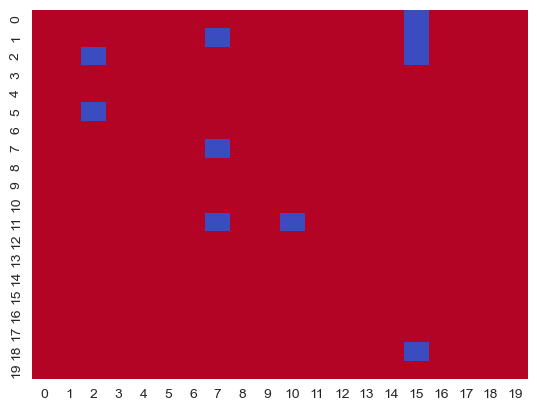

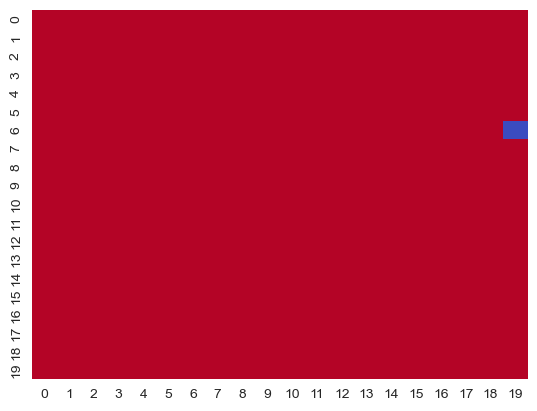

In [54]:
visualize_grid(mcmc_grid_hot)
visualize_grid(wolff_grid_hot)

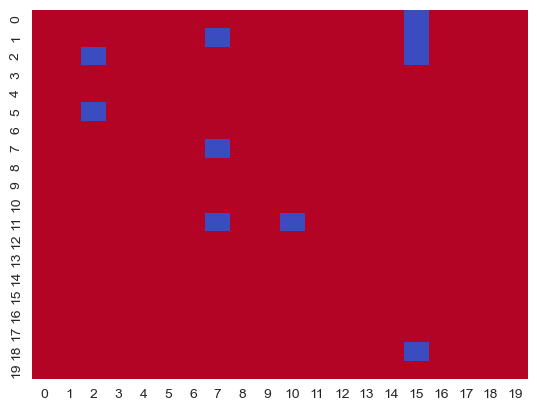

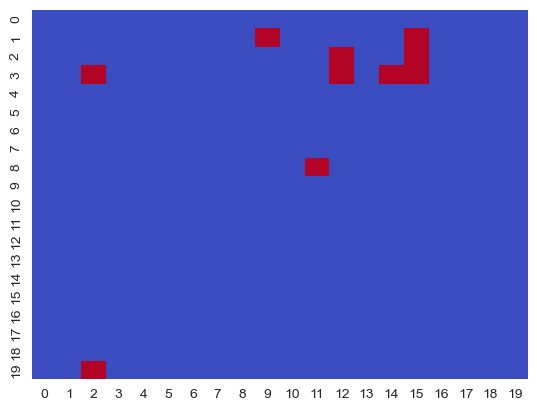

In [55]:
visualize_grid(mcmc_grid_hot)
visualize_grid(wolff_grid_rand)

## Beta plots

In [56]:
import time
import numpy as np
from tqdm import tqdm
from copy import deepcopy

def run_complete_simulation(step_func, betas, initial_grids, steps, burn_in):
    """
    Przeprowadza symulację dla wszystkich beta i wszystkich stanów początkowych.
    Zwraca słownik z wynikami: mag, en, sus oraz czasy wykonania.
    """
    results = {
        'mag': [],
        'en': [],
        'sus': [],
        'times': []
    }

    for beta in tqdm(betas, desc=f"Symulacja: {step_func.__name__}"):
        beta_mag, beta_en, beta_sus = [], [], []

        # Mierzymy czas tylko dla pierwszego przebiegu (Hot), aby mieć punkt odniesienia
        start_t = time.time()

        for i, grid in enumerate(initial_grids):
            # Wykonujemy symulację dla konkretnego stanu początkowego
            _, m, e, s = ising_simulation_with_stats(
                grid=deepcopy(grid),
                step_func=step_func,
                beta=beta,
                steps=steps,
                burn_in_steps=burn_in
            )

            beta_mag.append(m)
            beta_en.append(e)
            beta_sus.append(s)

            # Zapisujemy czas tylko po pierwszej (Hot) symulacji
            if i == 0:
                results['times'].append(time.time() - start_t)

        results['mag'].append(beta_mag)
        results['en'].append(beta_en)
        results['sus'].append(beta_sus)

    # Konwersja list na tablice numpy dla łatwiejszego plotowania
    results['mag'] = np.array(results['mag'])
    results['en'] = np.array(results['en'])
    results['sus'] = np.array(results['sus'])

    return results

In [57]:
# Wspólne parametry
betas = np.arange(0, 1, 0.05)
grids = [grid_hot, grid_cold, grid_random]

# 1. Symulacja Metropolis
stats_metropolis = run_complete_simulation(
    step_func=monte_carlo_metropolis_step,
    betas=betas,
    initial_grids=grids,
    steps=3000,
    burn_in=500
)

# 2. Symulacja Wolff
stats_wolff = run_complete_simulation(
    step_func=wolff_step,
    betas=betas,
    initial_grids=grids,
    steps=3000,
    burn_in=500
)

stats_metropolis_short = run_complete_simulation(
    step_func=monte_carlo_metropolis_step,
    betas=betas,
    initial_grids=grids,
    steps=500,
    burn_in=100
)

# 2. Symulacja Wolff
stats_wolff_short = run_complete_simulation(
    step_func=wolff_step,
    betas=betas,
    initial_grids=grids,
    steps=500,
    burn_in=100
)

Symulacja: wolff_step: 100%|██████████| 20/20 [00:08<00:00,  2.37it/s]


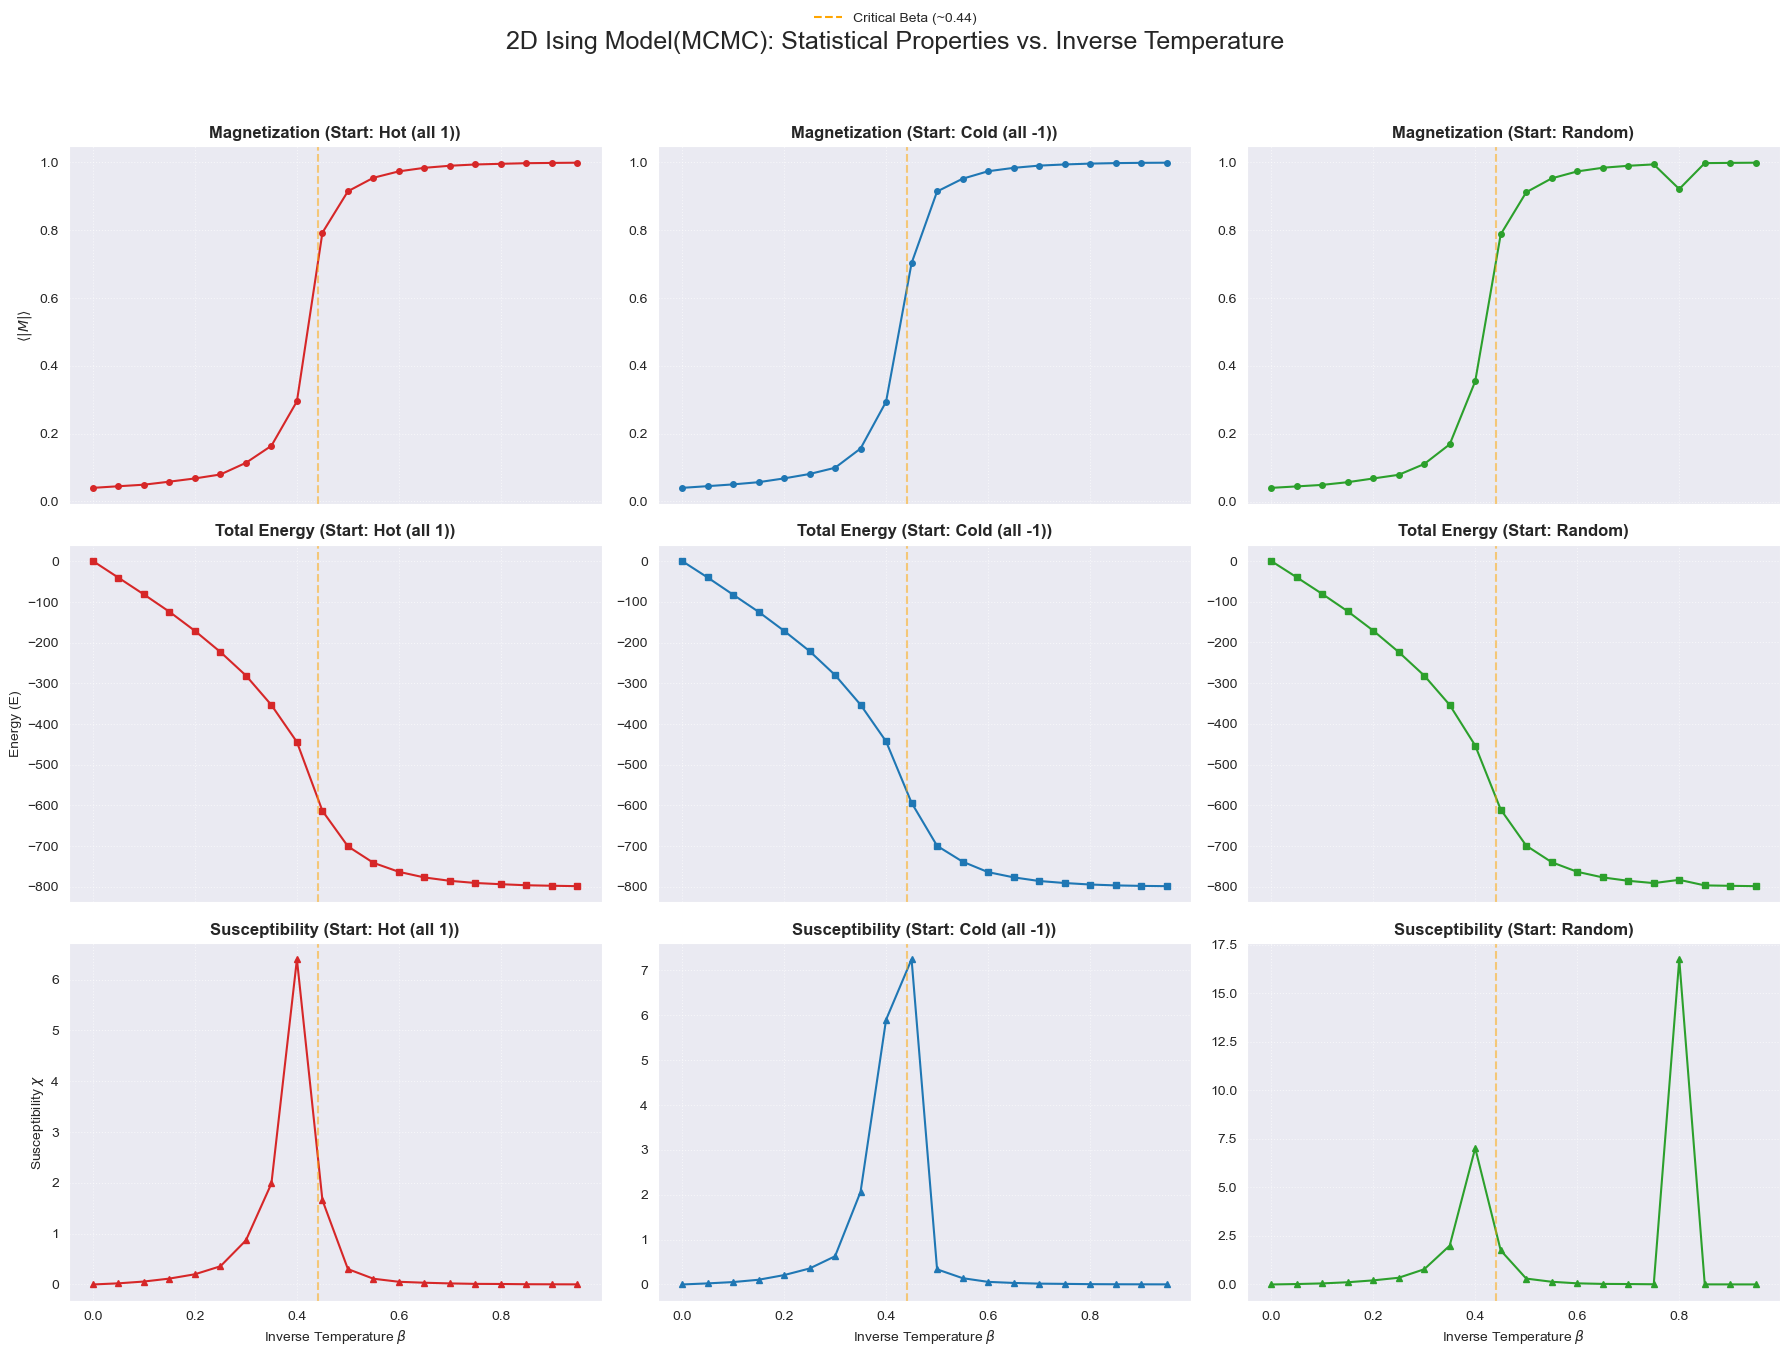

In [58]:
plot_stats(mag = stats_metropolis['mag'], tot_en = stats_metropolis['en'], sus = stats_metropolis['sus'], title_model="MCMC")

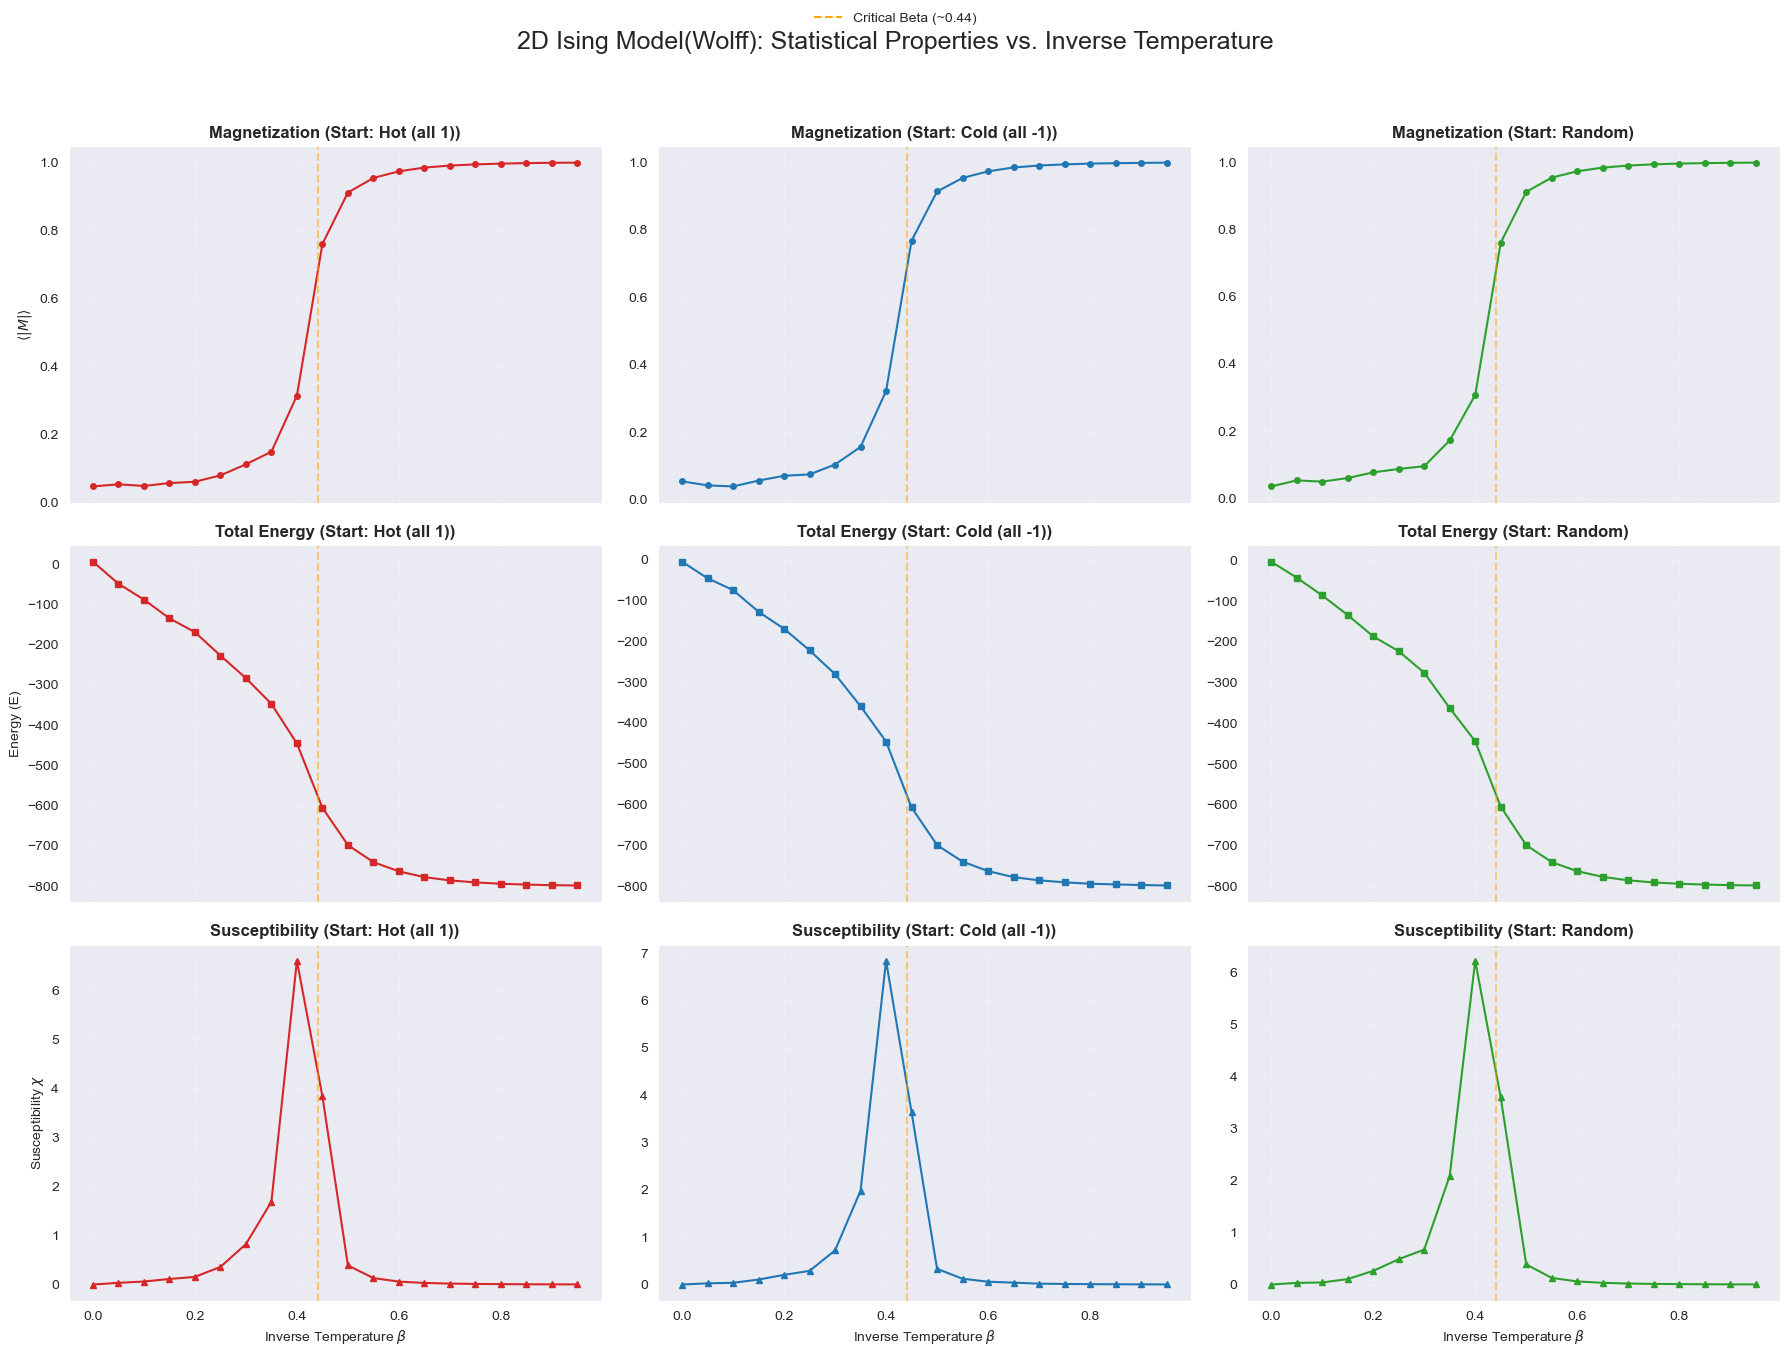

In [59]:
plot_stats(mag = stats_wolff['mag'], tot_en = stats_wolff['en'], sus = stats_wolff['sus'], title_model="Wolff")

## Comparison

### First lets see comparison for 3000 steps

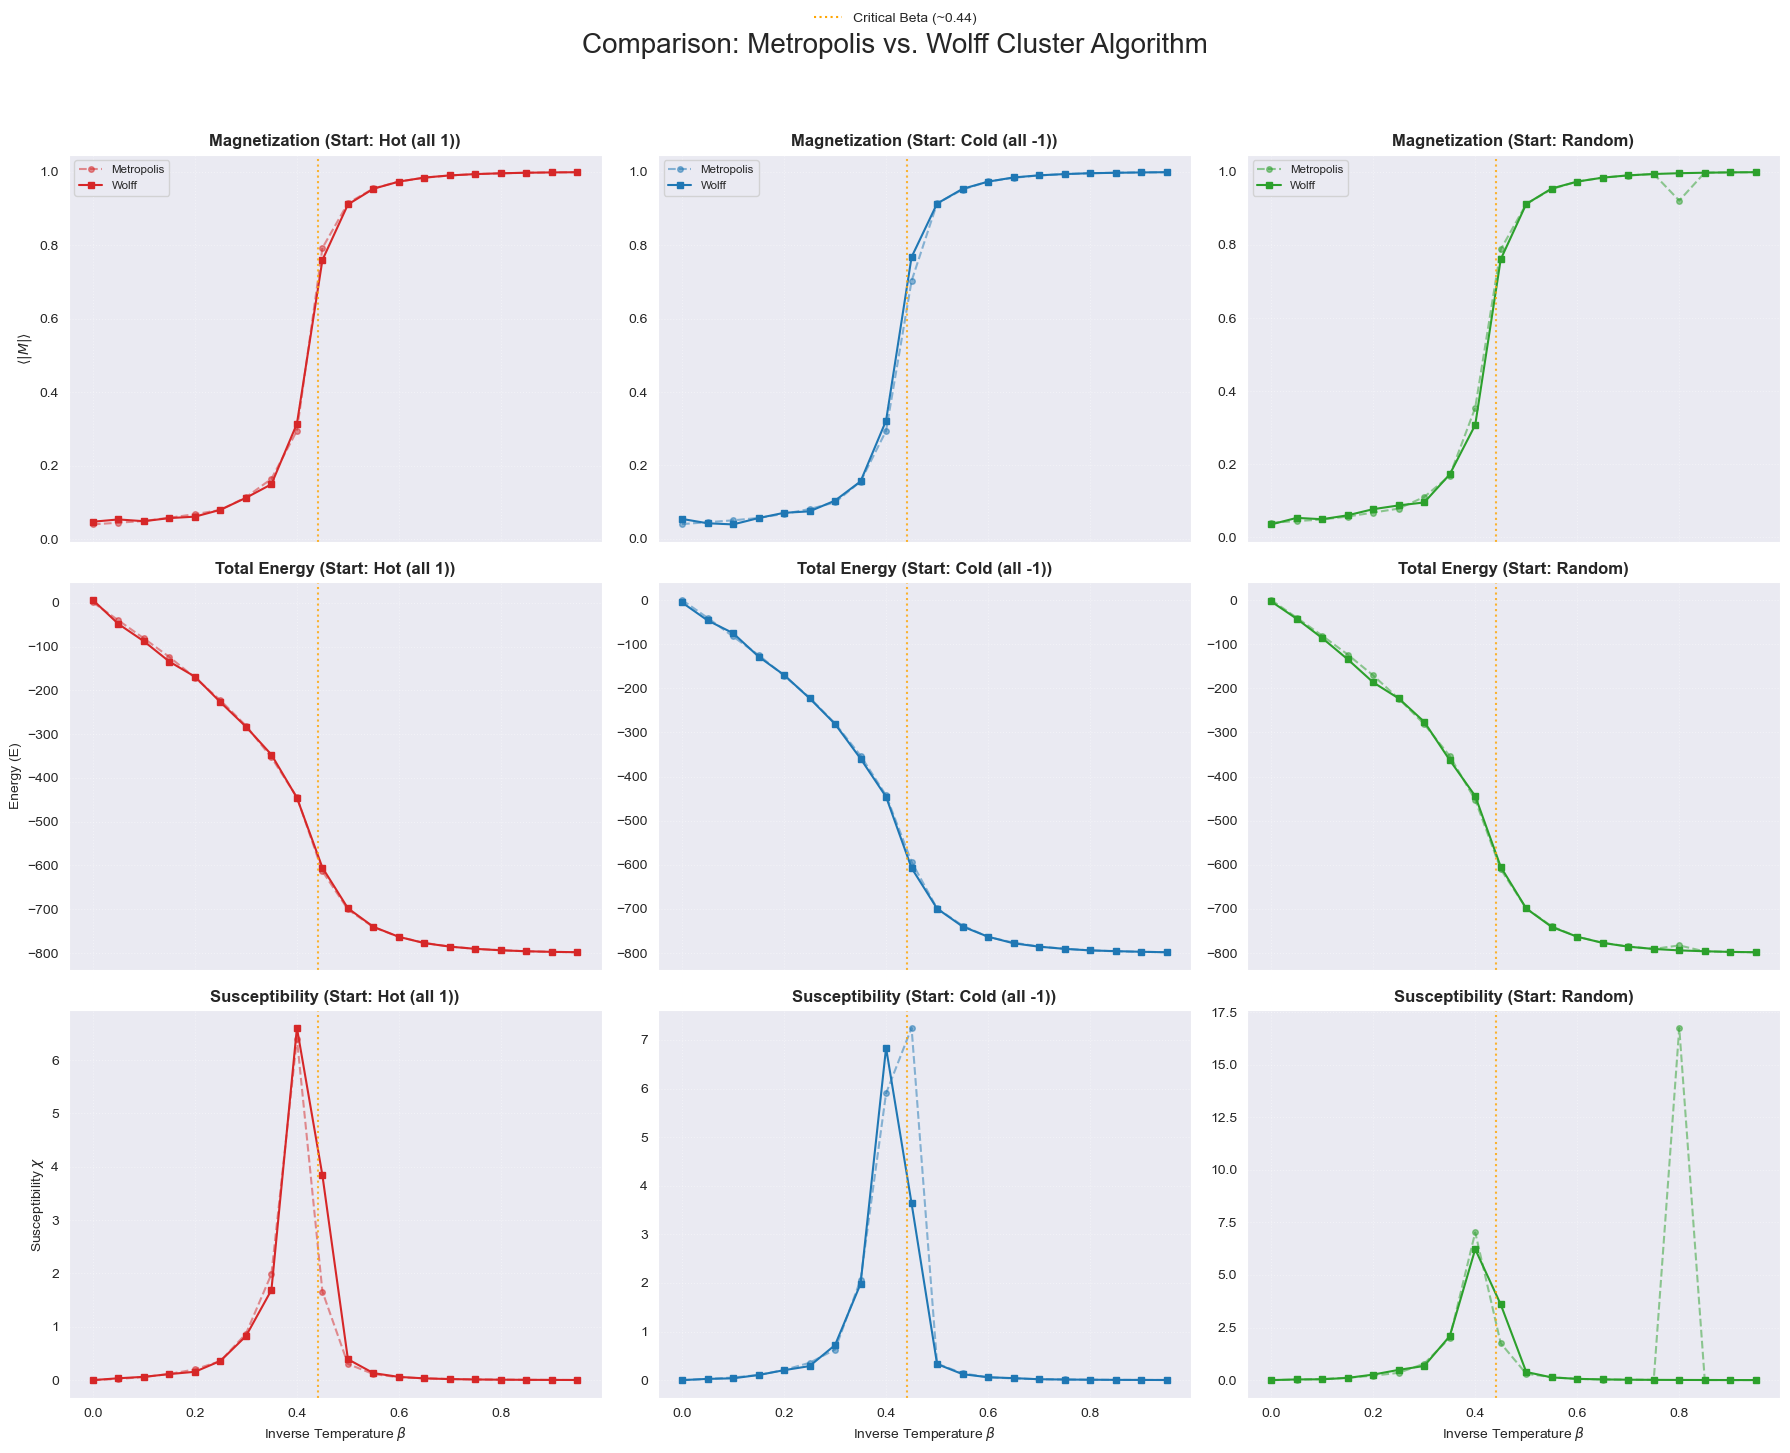

In [60]:
plot_comparison(
    mag_met=stats_metropolis['mag'],
    en_met=stats_metropolis['en'],
    sus_met=stats_metropolis['sus'],
    mag_wolff=stats_wolff['mag'],
    en_wolff=stats_wolff['en'],
    sus_wolff=stats_wolff['sus'])

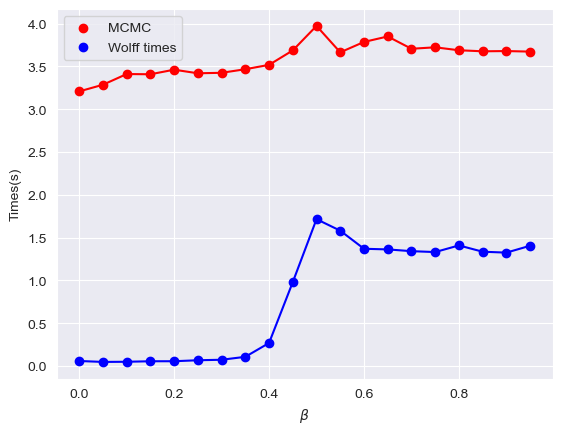

In [61]:
plt.scatter(betas,stats_metropolis['times'], color="red",label="MCMC")
plt.plot(betas,stats_metropolis['times'], color="red")
plt.scatter(betas,stats_wolff['times'], color="blue",label="Wolff times")
plt.plot(betas,stats_wolff['times'], color="blue")

plt.xlabel(r"$\beta$")
plt.ylabel("Times(s)")

plt.legend()
plt.show()

### Now lets compare it with much lesser number of steps which is around 500

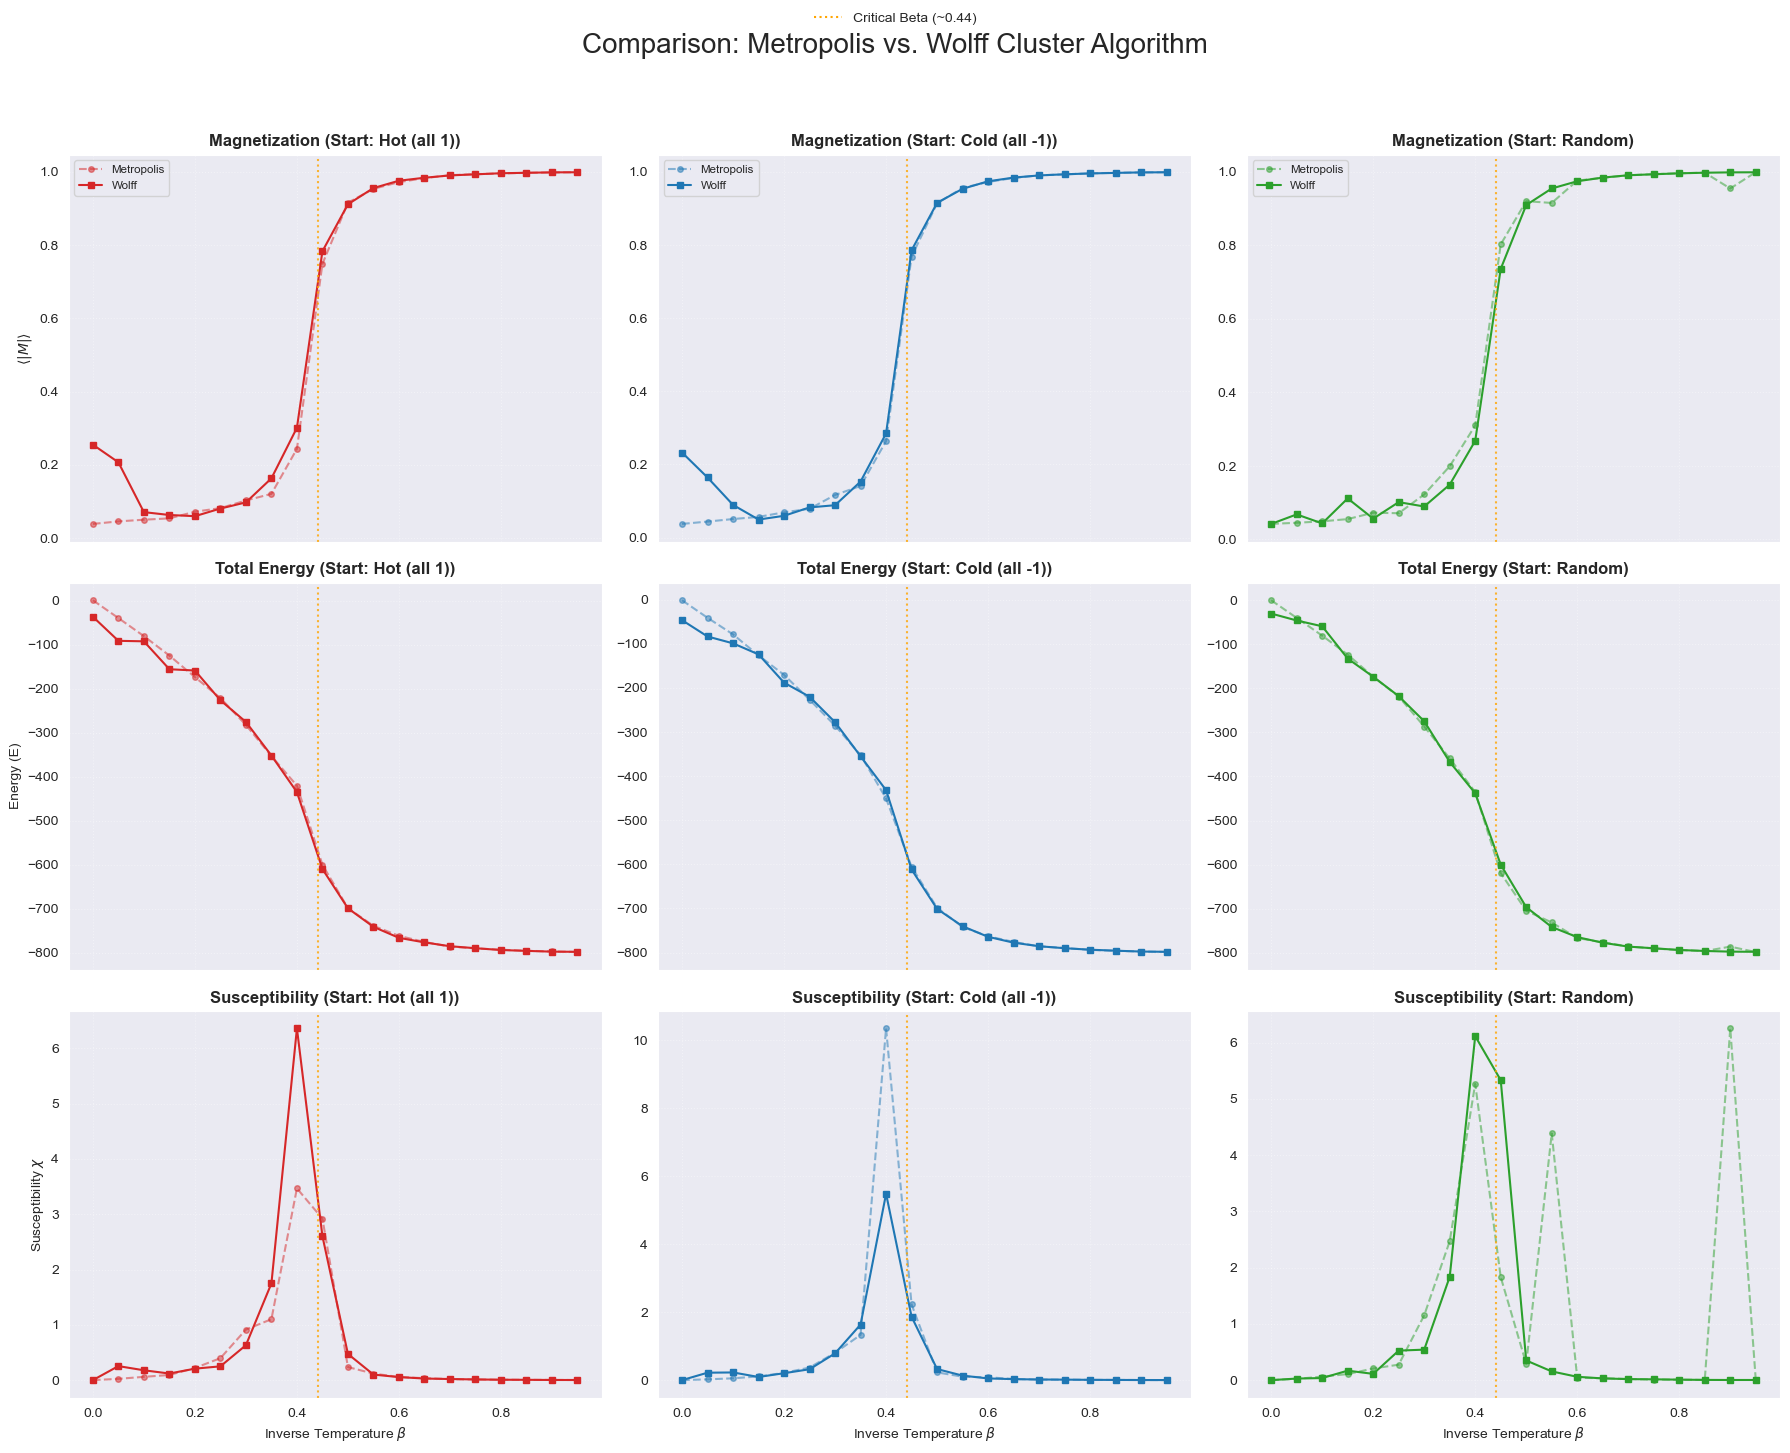

In [62]:
plot_comparison(
    mag_met=stats_metropolis_short['mag'],
    en_met=stats_metropolis_short['en'],
    sus_met=stats_metropolis_short['sus'],
    mag_wolff=stats_wolff_short['mag'],
    en_wolff=stats_wolff_short['en'],
    sus_wolff=stats_wolff_short['sus'])

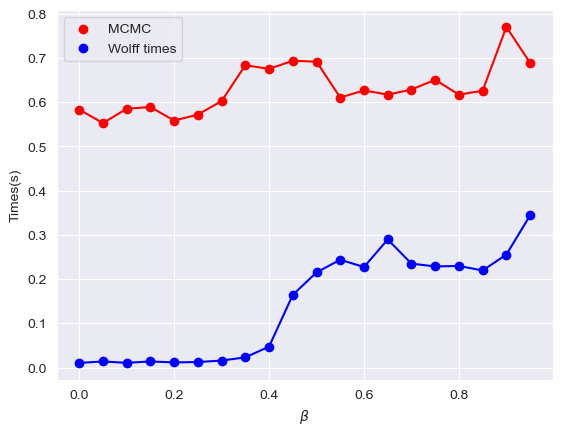

In [63]:
plt.scatter(betas,stats_metropolis_short['times'], color="red",label="MCMC")
plt.plot(betas,stats_metropolis_short['times'], color="red")
plt.scatter(betas,stats_wolff_short['times'], color="blue",label="Wolff times")
plt.plot(betas,stats_wolff_short['times'], color="blue")

plt.xlabel(r"$\beta$")
plt.ylabel("Times(s)")

plt.legend()
plt.show()

## Conclusions

### 1. Autocorrelation and Cluster Dynamics
* **Lower Autocorrelation**: The Wolff algorithm is characterized by significantly lower autocorrelation compared to the Metropolis algorithm because it operates on entire clusters of spins rather than individual points.
* **Critical Slowing Down**: By effectively eliminating the phenomenon of "critical slowing down," Wolff achieves faster convergence and provides precise results near the critical point ($\beta \approx 0.44$) even with a relatively small number of steps.
* **Efficiency**: A single step of the Wolff algorithm can lead to the reversal of a much larger number of spins than a single iteration of Metropolis. This makes it a far more efficient tool for studying the dynamics of lattice models.

### 2. Impact of Initial State (Hot vs. Cold Start)
* **Relaxation and Ordering**: It was observed that critical states are more clearly visible when starting from "Cold" (ordered) or "Hot" (fully random) configurations.
* **Energy Conflicts**: A random "Hot" grid requires a longer period to "clear" local energy conflicts and domains compared to a "Cold" grid, which starts from a global minimum.
* **Thermalization**: For random grids, ensuring an adequate `burn-in` period is crucial to allow the system to "forget" the high-entropy initial state before data collection begins.

### 3. Algorithm Equivalence and Stability
* **Regional Equivalence**: Outside the phase transition region, both algorithms yield very similar results.
* **Summary**: The Wolff algorithm serves as an excellent alternative to standard MCMC (Metropolis), offering greater statistical stability and superior performance in the most critical areas of the simulation. There might be some numerical instabilities which gives sometimes strange looking result, adding steps make it more stable.